work for double peak analysis/generation

first, import stuff

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import re

now, i need it to get the data list and load it

In [2]:
file_path = '/home/tachyon/fermi_project/hessi/data/hessi_flare_list.txt'

parsed_data = []

try:
    with open(file_path, 'r') as file:
        for line in file:
            clean_line = line.strip()
            
            # Data rows start with a numeric Flare ID
            if clean_line and clean_line[0].isdigit():
                cols = re.split(r'\s+', clean_line)

                if len(cols) >= 12:
                    flare_id = cols[0]
                    start_time = f"{cols[1]} {cols[2]}"  
                    
                    # Active Region is sometimes missing at the end of the line
                    active_region = cols[12] if len(cols) > 12 else None 
                 
                    parsed_data.append([flare_id, start_time, active_region])

except FileNotFoundError:
    print(f"ERROR: Could not find the file at '{file_path}'.")



now i need to make a dataframe for the stuff

In [3]:
df = pd.DataFrame(parsed_data, columns=['flare_id', 'start_time', 'active_region'])

convert the timestamps

In [4]:
df['start_time'] = pd.to_datetime(df['start_time'], errors='coerce')
df = df.dropna(subset=['start_time'])

im gonna try to only use solar cycle 24 flares

In [5]:
cycle_24 = df[(df['start_time'] >= '2008-01-01') & (df['start_time'] <= '2019-12-31')].copy()

print(f"Found {len(cycle_24)} flares in Solar Cycle 24.")

Found 60205 flares in Solar Cycle 24.


now i wanna group them somehow to work in batches, maybe by month

In [6]:
cycle_24.set_index('start_time', inplace=True)
monthly_flare_counts = cycle_24.resample('ME').size()

now i want to start on the plots 

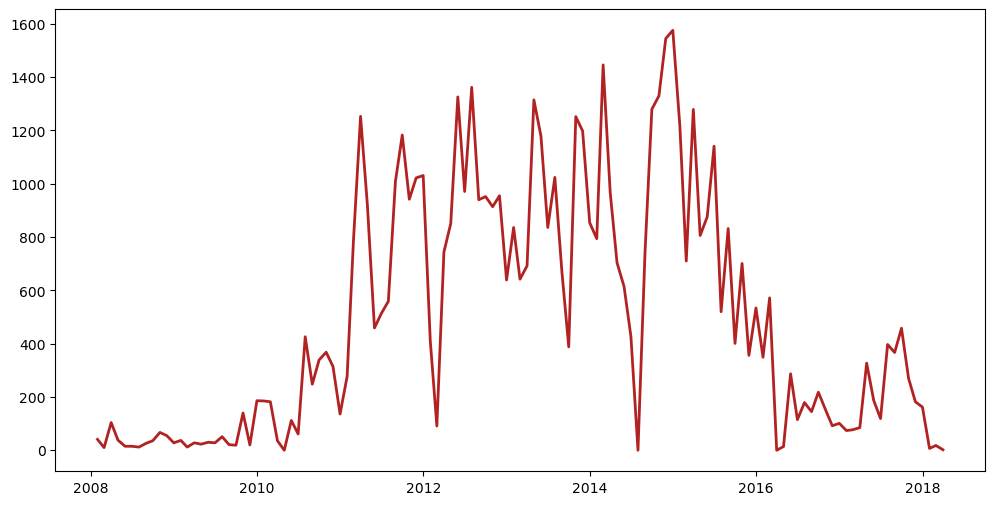

In [7]:
plt.figure(figsize=(12, 6))
plt.plot(monthly_flare_counts.index, monthly_flare_counts.values, color='firebrick', linewidth=2, label='Monthly Flare Count')

maybe i can further format them for the double peak stuff

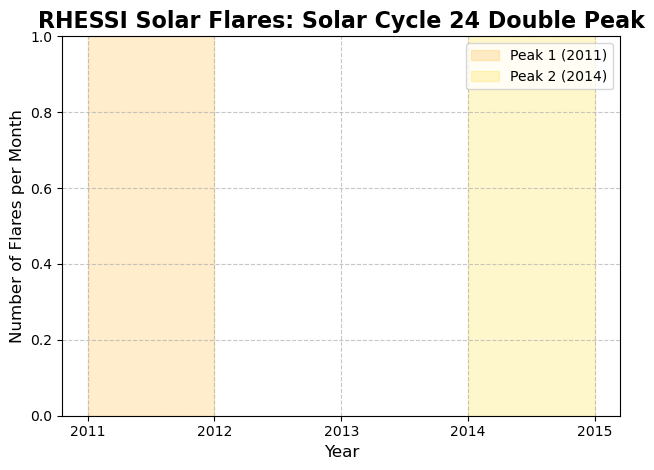

In [8]:
plt.title('RHESSI Solar Flares: Solar Cycle 24 Double Peak', fontsize=16, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Number of Flares per Month', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.gca().xaxis.set_major_locator(mdates.YearLocator())
plt.axvspan(pd.to_datetime('2011-01-01'), pd.to_datetime('2012-01-01'), color='orange', alpha=0.2, label='Peak 1 (2011)')
plt.axvspan(pd.to_datetime('2014-01-01'), pd.to_datetime('2015-01-01'), color='gold', alpha=0.2, label='Peak 2 (2014)')
plt.legend(loc='upper right')
plt.tight_layout()

get it to save the image

In [9]:
output_filename = 'cycle24_double_peak_tachyon.png'
plt.savefig(output_filename, dpi=300)
print(f"Success! Plot saved to your project folder as: {output_filename} ")

Success! Plot saved to your project folder as: cycle24_double_peak_tachyon.png 


<Figure size 640x480 with 0 Axes>